In [1]:
import numpy as np

def simatm(ngrid, pixel, lamb, r0, fhigh, zlow, zhigh, seed0=None):
    """
    Generation of complex amplitude resulting from 2 turbulent layers.
    Saves and returns the final ground-layer complex wavefront mask block.
    """
    size = 2 * ngrid * pixel
    
    # Calculate integrated turbulence structures
    tint0 = (r0**(-5./3.)) / 0.423 * (0.5 * lamb / np.pi)**2
    see = (tint0 / 6.83e-13)**0.6
    
    tint1 = tint0 * fhigh          # High layer strength
    tint2 = tint0 * (1. - fhigh)   # Low layer strength
    
    if zlow > zhigh:
        raise ValueError("zlow cannot be higher than zhigh.")
        
    # Calculate unique Fried parameters for both components
    r01 = (0.423 * (0.5 * lamb / np.pi)**(-2) * tint1)**(-3./5.) if tint1 > 0 else np.inf
    r02 = (0.423 * (0.5 * lamb / np.pi)**(-2) * tint2)**(-3./5.) if tint2 > 0 else np.inf
    
    print("--- simatm setup environment ---")
    print(f"Grid size [m]:                     {size:.4f}")
    print(f"Fried parameters [low, high] [m]:  {r02:.4f}, {r01:.4f}")
    print(f"Altitudes [low, high] [m]:         {zlow}, {zhigh}")
    
    fact1 = np.sqrt(0.023) * (size / r01)**(5./6.) if r01 != np.inf else 0.0
    fact2 = np.sqrt(0.023) * (size / r02)**(5./6.)
    
    # 2D Grid Setup
    y, x = np.ogrid[-ngrid:ngrid, -ngrid:ngrid]
    r = np.sqrt(x**2 + y**2)
    # Correct coordinate shifts to match the centered array positioning logic
    r = np.fft.fftshift(r)
    
    # Inject singularity guard at the optical center point
    r[0, 0] = 1.e-3
    
    # Fresnel Filter argument arrays
    farg = np.pi * lamb / (size**2) * (r**2)
    
    # Seed configuration management
    if seed0 is not None:
        np.random.seed(seed0)
        
    # --- LAYER 1: HIGH TURBULENT LAYER ---
    if fhigh > 0.0:
        print("Simulating the high screen...")
        rand_complex = np.random.normal(0, 1, (2*ngrid, 2*ngrid)) + 1j * np.random.normal(0, 1, (2*ngrid, 2*ngrid))
        tmp_ft = fact1 * (r**(-11./6.)) * rand_complex
        tmp_ft[0, 0] = 0.0 + 0.1j
        
        tmp_phase = np.fft.ifft2(tmp_ft).real * (2 * ngrid)**2
        u1 = np.cos(tmp_phase) + 1j * np.sin(tmp_phase)
        
        # Propagate wavefront down through the empty space separating the high layer from low layer
        if (zhigh - zlow) > 0.0:
            print("Propagating to low layer...")
            u1_ft = np.fft.fft2(u1)
            prop_filter = np.cos(farg * (zhigh - zlow)) - 1j * np.sin(farg * (zhigh - zlow))
            u1 = np.fft.ifft2(u1_ft * prop_filter)
    else:
        u1 = np.ones((2*ngrid, 2*ngrid), dtype=complex)
        
    # --- LAYER 2: LOW TURBULENT LAYER ---
    print("Simulating the low screen...")
    rand_complex_low = np.random.normal(0, 1, (2*ngrid, 2*ngrid)) + 1j * np.random.normal(0, 1, (2*ngrid, 2*ngrid))
    tmp_ft_low = fact2 * (r**(-11./6.)) * rand_complex_low
    tmp_ft_low[0, 0] = 0.0 + 0.0j
    
    tmp_phase_low = np.fft.ifft2(tmp_ft_low).real * (2 * ngrid)**2
    u1 *= (np.cos(tmp_phase_low) + 1j * np.sin(tmp_phase_low))
    
    # --- FINAL PROPAGATION STEP TO GROUND TELESCOPE CORNEA ---
    print("Propagating to ground...")
    u1_ground_ft = np.fft.fft2(u1)
    ground_filter = np.cos(farg * zlow) - 1j * np.sin(farg * zlow)
    u1 = np.fft.ifft2(u1_ground_ft * ground_filter)
    
    # Evaluate simulated scintillation index performance vs standard analytical Rytov
    scind = np.var(np.abs(u1)**2)
    rytov = 19.22 * lamb**(-7./6.) * (zlow**(5./6.) * tint2 + zhigh**(5./6.) * tint1)
    print(f"Rytov variance [Analytical vs Simulated]: {rytov:.5f} vs {scind:.5f}\n")
    
    # Pack parameters up clean into an exchangeable dictionary workspace
    atm_dataset = {
        'u1': u1, 'ngrid': ngrid, 'pixel': pixel, 'lamb': lamb,
        'see': see, 'r0': r0, 'fhigh': fhigh, 'zhigh': zhigh, 'zlow': zlow
    }
    return atm_dataset

In [2]:
import logging
from scipy.ndimage import zoom, map_coordinates
from IPython.display import display

# Setup minimal logger tracking footprint config
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger("ringsim")

def ringsim(par, atm_data, starmag=2.0, ron=1.0, wind=10.0, blur=False, jitter=None):
    """
    Monte-Carlo optical simulation of dynamic defocus donut ring geometries tracking over noise.
    """
    # Unpack telescope container objects
    D = par['D']
    eps = par['eps']
    pdist = par['pdist']
    lamb = par['lambda']
    
    texp = 0.001
    tacc = 2.0
    
    # Safely duplicate background context data parameters from your atmosphere matrix dictionary
    u1 = atm_data['u1'].copy()
    ngrid = atm_data['ngrid']
    pixel = atm_data['pixel']
    r0 = atm_data['r0']
    
    if lamb != par['lambda']:
        raise ValueError(f"Mismatch in simulated wavelength. Use {par['lambda']}")
        
    # --- ATMOSPHERIC EXPOSURE SMARING (BLUR) ---
    if blur:
        nblur = int(wind * texp / pixel + 0.5)
        print(f"Averaging atmospheric screens, N={nblur}")
        if nblur > 1:
            tmp = u1.copy()
            for k in range(1, nblur):
                tmp += np.roll(u1, shift=k, axis=1)
            u1 = tmp / nblur

    size = 2 * ngrid * pixel
    slide = 0.205
    alpha = slide / size
    
    niter = int(np.floor(tacc / texp + 1))
    jstep = int(np.floor(wind * texp / pixel + 0.5))
    if jstep < 1: 
        jstep = 1
    windef = jstep * pixel / texp
    
    print(f"Screen shift per exposure [pixels]: {jstep}")
    print(f"Effective simulated wind speed [m/s]: {windef:.2f}")
    
    # Grid Resampling Configuration
    nap = int(ngrid / 2)
    d1 = (lamb / par['pixel']) * 206265.0
    
    npixperpix = int(2**(np.floor(np.log2(1.5 * D / d1)) + 1))
    nscr = int(2**(np.floor(np.log2(1.5 * D / pixel)) + 1))
    ksamp = max(nap / nscr, 1.0)
    
    asperpix = par['pixel']
    nccd_full = int(nap / npixperpix)
    
    # Handle crop configuration to strict 32x32 pixel matrix boundary regions safely
    roi_size = 32
    nccd = min(roi_size, nccd_full)
    
    ringradpix = 0.85 * D * (1 + eps) / (4.0 * pdist) * 206265.0 / asperpix
    print(f"Nominal ring radius [pix]:        {ringradpix:.2f}")
    print(f"Full mathematical CCD size:       {nccd_full}x{nccd_full}")
    print(f"Target Cropped ROI matrix layout: {nccd}x{nccd}")
    
    # Calculate star counts
    if starmag != 0.0:
        BW = 0.26
        starph = 1.e11 * texp * BW * 10**(-0.4 * starmag) * np.pi * (D / 2.0)**2 * (1. - eps)**2
        print(f"Stellar flux intensity [photons]: {starph:.2f}\n")
        
    # --- CONSTRUCT APERTURE MASK MESH ---
    y_idx, x_idx = np.indices((nap, nap))
    center = nap / 2.0
    r_grid = np.sqrt((x_idx - center)**2 + (y_idx - center)**2)
    
    Radpix = D * 0.5 / pixel * ksamp
    apert = np.zeros((nap, nap))
    inside = (r_grid <= Radpix) & (r_grid >= Radpix * eps)
    apert[inside] = 1.0
    
    # --- DEFOCUS AND SPHERICAL ZERNIKE CALCULATIONS ---
    a4 = (D**2 / (lamb * pdist)) * (np.pi / (8.0 * np.sqrt(3.0)))
    a11 = -0.1 * a4
    
    rho = r_grid / Radpix
    tmp_phase = a11 * np.sqrt(5.0) * (6.0 * rho**4 - 6.0 * rho**2)
    tmp_phase += a4 * 2.0 * np.sqrt(3.0) * (rho**2 - 0.5)
    zernike_phase = tmp_phase * apert
    
    fresnel = np.exp(1j * zernike_phase) * apert
    
    # Generate the baseline stationary un-distorted reference ring pattern
    imh0_complex = np.fft.ifft2(np.fft.ifftshift(fresnel))
    imh0 = np.abs(np.fft.fftshift(imh0_complex))**2
    normconst = np.sum(imh0)
    
    # Tracking structural loops config setups
    cube = np.zeros((niter, nccd, nccd))
    ix = 0
    y_float = 0.0
    omega = 3.3 / niter * (2.0 * np.pi)
    
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(figsize=(4, 4))
    im_handle = None
    
    print(f"Computing {niter} simulation cycles...")
    
    for i in range(niter):
        ix += jstep
        y_float += jstep * alpha
        iy = int(np.floor(y_float))
        
        # Enforce wrapping constraints smoothly around boundary edges
        if ix >= ngrid:
            u1 = np.roll(u1, -ngrid, axis=1)
            ix -= ngrid
        if iy >= ngrid:
            u1 = np.roll(u1, -ngrid, axis=0)
            y_float -= ngrid
            iy = int(np.floor(y_float))
            
        uampl = u1[iy : iy + nscr, ix : ix + nscr]
        
        if ksamp > 1.0:
            # Safely scale complex wavefront transformations by handling phase component separately
            uampl_phase = np.angle(uampl)
            zoomed_phase = zoom(uampl_phase, nap / nscr, order=1)
            uampl = np.exp(1j * zoomed_phase)
            
        # Complete optical propagation
        wavefront = fresnel * uampl
        imh1_complex = np.fft.ifft2(np.fft.ifftshift(wavefront))
        imh1 = np.abs(np.fft.fftshift(imh1_complex))**2
        
        # Run resolution binning down to detector matrix size scaling parameters
        if npixperpix > 1:
            impix = imh1.reshape(nccd_full, npixperpix, nccd_full, npixperpix).sum(axis=(1, 3))
        else:
            impix = imh1.copy()
            
        # Isolate center ROI window tracking area slice precisely
        center_idx = nccd_full // 2
        half_roi = nccd // 2
        impix = impix[center_idx - half_roi : center_idx + half_roi, 
                      center_idx - half_roi : center_idx + half_roi]
        
        # Local matrix configuration normalization alignment
        loop_sum = np.sum(impix)
        if loop_sum > 0:
            impix = (impix * (npixperpix**2)) / normconst
            
        # Inject tracking stabilization loop platform jitter
        if jitter is not None:
            xc = jitter * np.cos(i * omega)
            yc = jitter * np.sin(i * omega)
            coords = np.meshgrid(np.arange(nccd) + yc, np.arange(nccd) + xc, indexing='ij')
            impix = map_coordinates(impix, coords, order=1)
            
        # Apply stochastic quantum photon detection and instrument read-noise profiles
        if starmag != 0.0:
            impix *= starph
            impix = np.random.poisson(impix).astype(float)
            impix += np.random.normal(0, ron, (nccd, nccd))
            
        cube[i, :, :] = impix
        
        # --- TARGETED NON-FLICKERING LIVE DISPLAY BLOCK ---
        if im_handle is None:
            im_handle = ax.imshow(impix, cmap='gray', origin='lower')
            ax.set_title(f"Frame: {i+1} / {niter}")
            display_handle = display(fig, display_id=True)
        elif i % 40 == 0:
            im_handle.set_data(impix)
            im_handle.set_clim(vmin=impix.min(), vmax=impix.max())
            ax.set_title(f"Frame: {i+1} / {niter}")
            display_handle.update(fig)
            
    plt.close(fig)
    print("Simulation execution complete.")
    return cube

Configuring Run -> Derived Target System Base r0: 0.1011 meters

--- simatm setup environment ---
Grid size [m]:                     18.0879
Fried parameters [low, high] [m]:  0.1077, 0.4024
Altitudes [low, high] [m]:         500.0, 11000.0
Simulating the high screen...
Propagating to low layer...
Simulating the low screen...
Propagating to ground...
Rytov variance [Analytical vs Simulated]: 0.11575 vs 0.08414

Screen shift per exposure [pixels]: 1
Effective simulated wind speed [m/s]: 17.66
Nominal ring radius [pix]:        4931.02
Full mathematical CCD size:       128x128
Target Cropped ROI matrix layout: 32x32
Stellar flux intensity [photons]: 1367382.26

Computing 2001 simulation cycles...


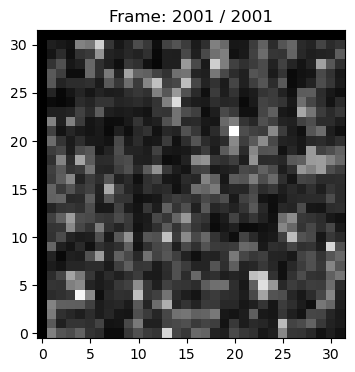

Simulation execution complete.


In [3]:
# 1. Manually initialize instrument structural parameters (simulating 'sim1.par')
instrument_parameters = {
    'D': 1.0,               # Telescope mirror diameter clear size boundary [meters]
    'eps': 0.35,            # Central secondary obstruction obscuration linear fraction ratio [0-1]
    'pdist': 120.0,         # Defocus depth translation target alignment offset height [meters]
    'lambda': 0.5e-6,       # Center analysis lightwave band parameter channel [meters]
    'pixel': 0.1,           # Detector configuration resolution plate-scale [arcseconds per pixel]
    'ron': 1.5              # Detector configuration electronic readout floor [electrons RMS]
}

# 2. Setup external operational variables environment parameters
seeing_arcsec = 1.0         # Spatial atmospheric turbulence sizing boundary profile [arcseconds]
zlow_altitude = 500.0       # Ground boundary boundary altitude layer height [meters]
zhigh_altitude = 11000.0    # High tropopause boundary altitude layer height [meters]
high_layer_fraction = 0.1   # Percentage split assignment distribution factor parameter
target_magnitude = 2.0      # Star brightness magnitude tracking parameter configuration

# Calculate unified baseline atmospheric Fried parameter metric structure models
derived_r0 = 0.98 * instrument_parameters['lambda'] / seeing_arcsec * 206265.0

print(f"Configuring Run -> Derived Target System Base r0: {derived_r0:.4f} meters\n")

# 3. Step A: Generate the raw dynamic complex atmosphere slice phase screens matrix array
atmosphere_workspace = simatm(
    ngrid=512, 
    pixel=0.017664, 
    lamb=instrument_parameters['lambda'], 
    r0=derived_r0, 
    fhigh=high_layer_fraction, 
    zlow=zlow_altitude, 
    zhigh=zhigh_altitude, 
    seed0=42
)

# 4. Step B: Pipe configuration structures smoothly down into the focal propagation runtime
data_cube = ringsim(
    par=instrument_parameters, 
    atm_data=atmosphere_workspace, 
    starmag=target_magnitude, 
    ron=instrument_parameters['ron'], 
    wind=5.0, 
    blur=False, 
    jitter=0.2
)